In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
DATASET_PATH = "/content/drive/MyDrive/IITG dataset/cleaned_dataset"
METADATA_PATH = os.path.join(DATASET_PATH, "metadata.csv")

metadata = pd.read_csv(METADATA_PATH)

print("Metadata shape:", metadata.shape)
display(metadata.head())

Metadata shape: (7565, 10)


,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,0,1,00001.csv,1.6743047446975208,NaN,NaN
1,impedance,[2010. 7. 21. 16. 53. ...,24,B0047,1,2,00002.csv,NaN,0.05605783343888099,0.20097016584458333
2,charge,[2010. 7. 21. 17. 25. ...,4,B0047,2,3,00003.csv,NaN,NaN,NaN
3,impedance,[2010 7 21 20 31 5],24,B0047,3,4,00004.csv,NaN,0.05319185850921101,0.16473399914864734
4,discharge,[2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...,4,B0047,4,5,00005.csv,1.5243662105099023,NaN,NaN


In [4]:
capacity_df = metadata[
    (metadata["type"] == "discharge") &
    (pd.to_numeric(metadata["Capacity"], errors="coerce").notna())
].copy()

capacity_df["Capacity"] = pd.to_numeric(
    capacity_df["Capacity"],
    errors="coerce"
)

capacity_df = capacity_df.sort_values(
    ["battery_id", "test_id"]
).reset_index(drop=True)

print("Valid capacity records:", len(capacity_df))
display(
    capacity_df[
        ["battery_id", "test_id", "Capacity"]
    ].head(10)
)

Valid capacity records: 2769


,battery_id,test_id,Capacity
0,B0005,1,1.856487
1,B0005,3,1.846327
2,B0005,5,1.835349
3,B0005,7,1.835263
4,B0005,9,1.834646
5,B0005,11,1.835662
6,B0005,13,1.835146
7,B0005,15,1.825757
8,B0005,17,1.824774
9,B0005,19,1.824613


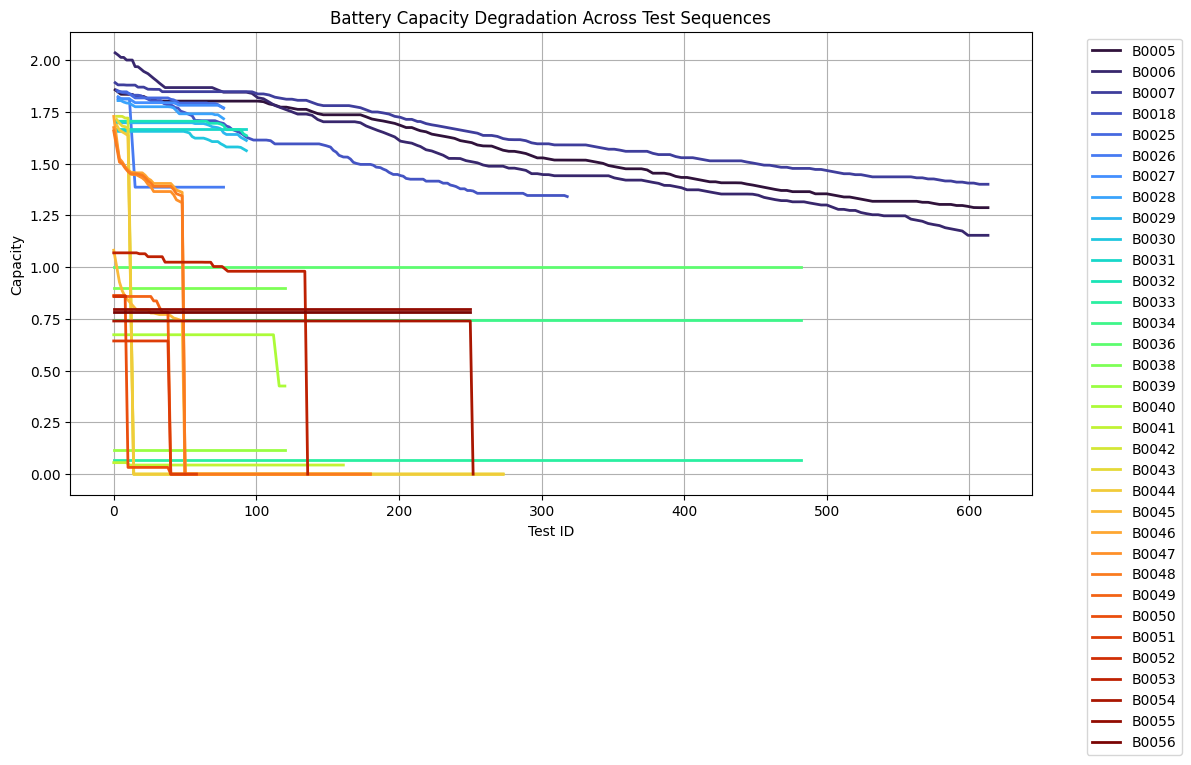

In [5]:
# Battery Capacity Degradation Across Test Sequences

import matplotlib.pyplot as plt

batteries = capacity_df["battery_id"].unique()
colors = plt.colormaps["turbo"].resampled(len(batteries))

plt.figure(figsize=(12, 7))

for i, battery in enumerate(batteries):
    battery_data = capacity_df[
        capacity_df["battery_id"] == battery
    ].sort_values("test_id").copy()

    # Remove upward hikes from capacity
    battery_data["Capacity_clean"] = battery_data["Capacity"].cummin()

    plt.plot(
        battery_data["test_id"],
        battery_data["Capacity_clean"],
        label=battery,
        color=colors(i),
        linewidth=2
    )

plt.xlabel("Test ID")
plt.ylabel("Capacity")
plt.title("Battery Capacity Degradation Across Test Sequences")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [7]:
capacity_df["reference_capacity"] = (
    capacity_df
    .groupby("battery_id")["Capacity"]
    .transform("max")
)

capacity_df["SoH"] = (
    capacity_df["Capacity"] /
    capacity_df["reference_capacity"]
) * 100

print("SoH range:")
print(capacity_df["SoH"].min(), "to", capacity_df["SoH"].max())

display(
    capacity_df[
        ["battery_id", "test_id", "Capacity",
         "reference_capacity", "SoH"]
    ].head(10)
)

SoH range:
0.0 to 100.0


,battery_id,test_id,Capacity,reference_capacity,SoH
0,B0005,1,1.856487,1.856487,100.000000
1,B0005,3,1.846327,1.856487,99.452721
2,B0005,5,1.835349,1.856487,98.861386
3,B0005,7,1.835263,1.856487,98.856718
4,B0005,9,1.834646,1.856487,98.823482
5,B0005,11,1.835662,1.856487,98.878217
6,B0005,13,1.835146,1.856487,98.850449
7,B0005,15,1.825757,1.856487,98.344690
8,B0005,17,1.824774,1.856487,98.291743
9,B0005,19,1.824613,1.856487,98.283094


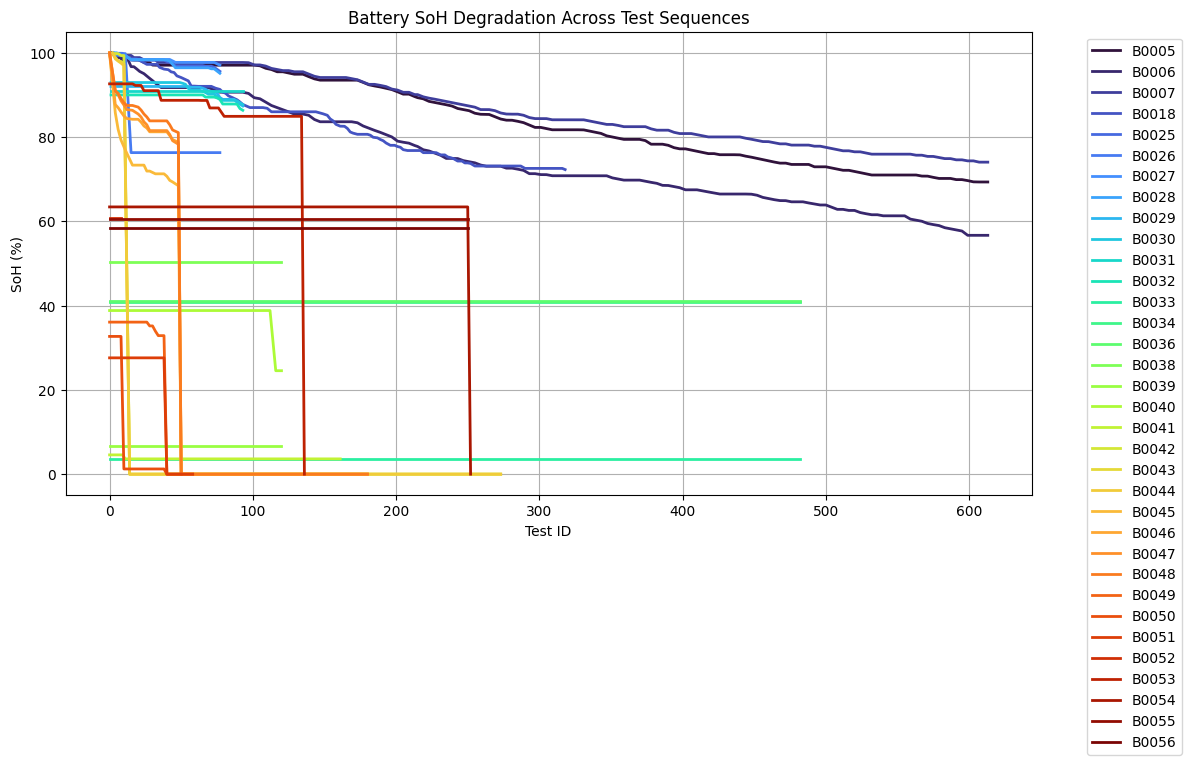

In [9]:
# Battery SoH Degradation Across Test Sequences

batteries = capacity_df["battery_id"].unique()
colors = plt.colormaps["turbo"].resampled(len(batteries))

plt.figure(figsize=(12, 7))

for i, battery in enumerate(batteries):
    battery_data = capacity_df[
        capacity_df["battery_id"] == battery
    ].sort_values("test_id").copy()

    # Remove upward hikes from SoH
    battery_data["SoH_clean"] = battery_data["SoH"].cummin()

    plt.plot(
        battery_data["test_id"],
        battery_data["SoH_clean"],
        label=battery,
        color=colors(i),
        linewidth=2
    )

plt.xlabel("Test ID")
plt.ylabel("SoH (%)")
plt.title("Battery SoH Degradation Across Test Sequences")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [ ]:
import glob
import os

DATA_PATH = os.path.join(DATASET_PATH, "data")

csv_files = glob.glob(
    os.path.join(DATA_PATH, "**", "*.csv"),
    recursive=True
)

print("Number of CSV files:", len(csv_files))
print("Example file:")
print(csv_files[0])

Number of CSV files: 7600
Example file:
/content/drive/MyDrive/IITG dataset/cleaned_dataset/data/06664.csv


In [ ]:
sample_df = pd.read_csv(csv_files[0])

print("Shape:", sample_df.shape)
print("\nColumns:")
print(sample_df.columns.tolist())

display(sample_df.head())

Shape: (1403, 6)

Columns:
['Voltage_measured', 'Current_measured', 'Temperature_measured', 'Current_charge', 'Voltage_charge', 'Time']


,Voltage_measured,Current_measured,Temperature_measured,Current_charge,Voltage_charge,Time
0,3.515781,-0.000839,33.942370,0.000,-0.007,0.000
1,3.194762,-3.612513,33.866384,-3.629,1.461,2.453
2,3.578757,1.515107,33.857983,1.507,4.289,9.422
3,3.635699,1.515922,33.863405,1.507,4.359,16.187
4,3.665379,1.515677,33.799425,1.507,4.392,22.937


Using file:
/content/drive/MyDrive/IITG dataset/cleaned_dataset/data/00001.csv


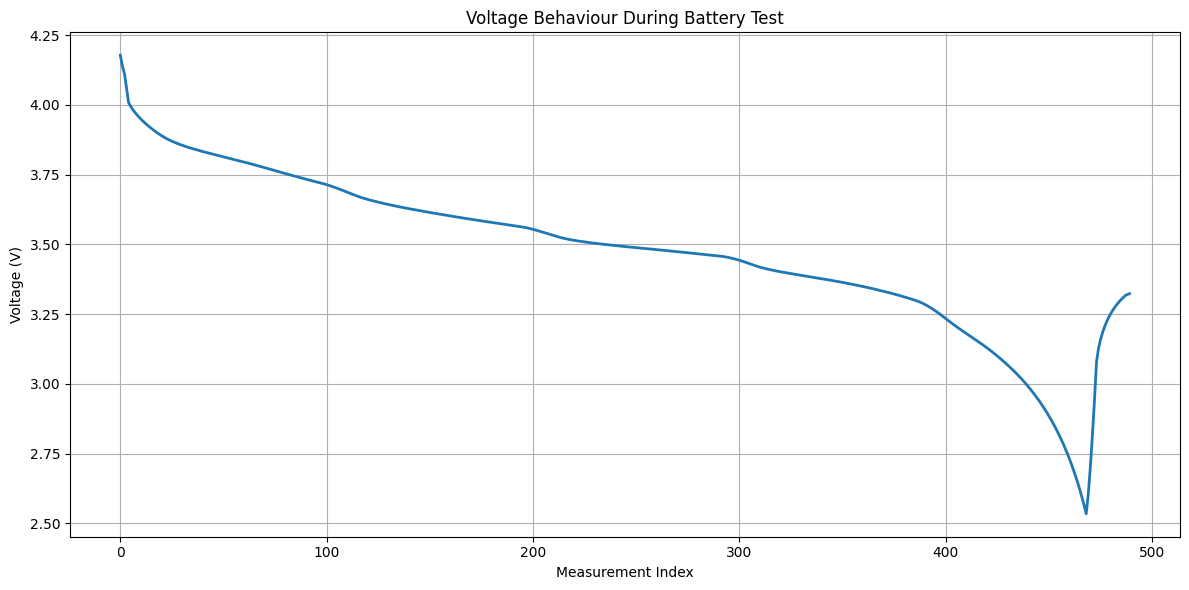

In [14]:
# Voltage Behaviour During Battery Test

import pandas as pd
import matplotlib.pyplot as plt
import os

# Find 00001.csv
target_file = None

for file in csv_files:
    if os.path.basename(file) == "00001.csv":
        target_file = file
        break

if target_file is None:
    print("00001.csv was not found.")
else:

    print("Using file:")
    print(target_file)

    # Load the correct CSV
    sample_df = pd.read_csv(target_file)

    # Convert voltage to numeric
    voltage = pd.to_numeric(
        sample_df["Voltage_measured"],
        errors="coerce"
    ).dropna()

    # Smooth only slightly
    voltage_smoothed = voltage.rolling(
        window=5,
        center=True,
        min_periods=1
    ).mean()

    # Plot
    plt.figure(figsize=(12, 6))

    plt.plot(
        voltage_smoothed,
        linewidth=2
    )

    plt.xlabel("Measurement Index")
    plt.ylabel("Voltage (V)")
    plt.title("Voltage Behaviour During Battery Test")
    plt.grid(True)

    plt.tight_layout()
    plt.show()

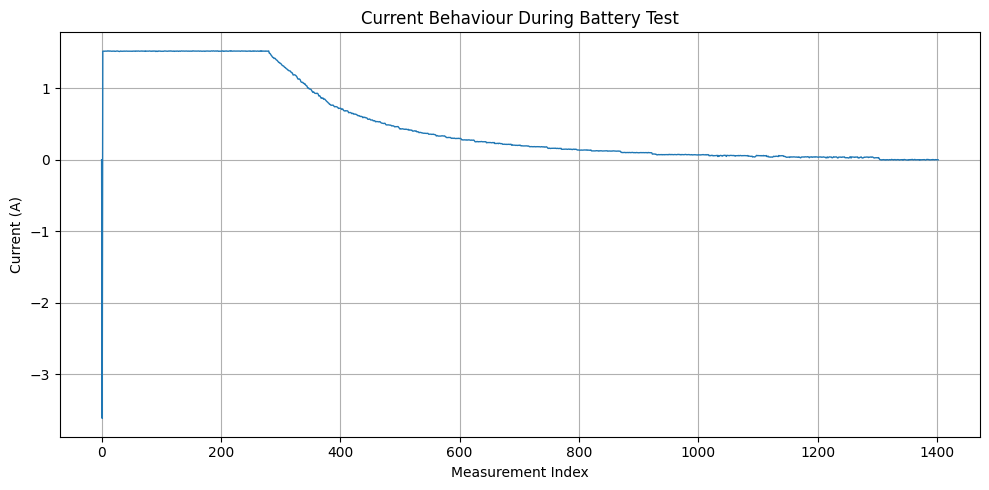

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    sample_df["Current_measured"],
    linewidth=1
)

plt.xlabel("Measurement Index")
plt.ylabel("Current (A)")
plt.title("Current Behaviour During Battery Test")
plt.grid(True)
plt.tight_layout()
plt.show()

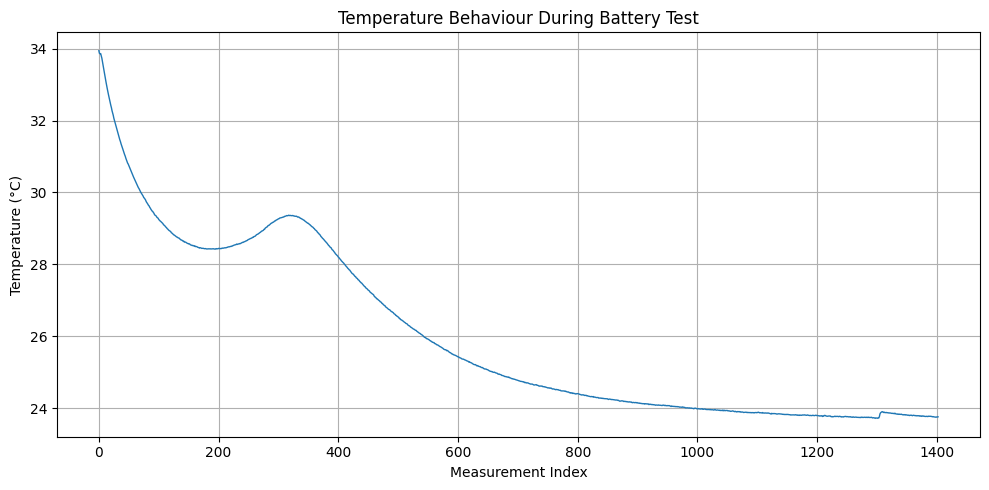

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    sample_df["Temperature_measured"],
    linewidth=1
)

plt.xlabel("Measurement Index")
plt.ylabel("Temperature (°C)")
plt.title("Temperature Behaviour During Battery Test")
plt.grid(True)
plt.tight_layout()
plt.show()